# Convolutional vision Transformer (CvT) from scratch in PyTorch

Combining the local smarts of Convolutional Neural Networks (CNNs) with the global reasoning of Vision Transformers (ViTs). The Convolutional Vision Transformer (CvT) is a hybrid architecture that marries the best of both worlds, CNNs and ViTs, by incorporating convolutional strengths into a transformer design.

https://arxiv.org/abs/2103.15808

In [ ]:
import os
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import inspect
import torch
import torch.nn as nn
import torch.nn.functional as F
from timm.layers import DropPath

In [ ]:
device= 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
# count how many trainable weights the model has
def count_parameters(model) -> None:
    total_params= sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Number of parameters: {total_params}')

# Define configs for different CvT versions

Due to their ability to model long-range dependencies and capture global context through self-attention, ViTs have shown impressive performance in many tasks. ViTs split images into fixed, non-overlapping patches, losing some spatial continuity and requiring positional embeddings to track patch locations. This characteristics makes ViTs:

- Data-Hungry: Need large datasets to learn spatial relationships.
- Resolution-Sensitive: Fixed embeddings struggle with varying image sizes.
- Compute-Heavy: Global attention scales poorly with large images. CvT addresses these by integrating convolutional layers, which naturally encode locality and adapt to different resolutions.

Why CvT Stands Out:

- No Positional Embeddings: Convolutions encode spatial information, making CvT flexible for varying resolutions.
- Efficiency: Depthwise separable convolutions reduce compute compared to ViT's linear projections.
- Multi-Scale Features: Hierarchical stages support dense tasks like segmentation.
- Generalization: Combines CNN's data efficiency with the transformer's scalability.

CvT is like a map that zooms into streets (local) while showing the city layout (global).

In [ ]:
# cvt_= d_model, n_layers, kernel_size, stride, d_ff_factor, n_heads, attn_kernel_size, attn_stride_q, attn_stride_kv
# (at each stage)
model_hparameters= {}
model_hparameters['cvt_13']= (
    [ 64, 192, 384], [1, 2, 10], [7, 3, 3], [4, 2, 2], 4, [1, 3, 6], [3, 3, 3], [1, 1, 1], [2, 2, 2],
)
model_hparameters['cvt_21']= (
    [ 64, 192, 384], [1, 4, 16], [7, 3, 3], [4, 2, 2], 4, [1, 3, 6], [3, 3, 3], [1, 1, 1], [2, 2, 2],
)
model_hparameters['cvt_w24']= (
    [192, 768,1024], [2, 2, 20], [7, 3, 3], [4, 2, 2], 4, [3, 12, 16], [3, 3, 3], [1, 1, 1], [2, 2, 2],
)

# Images to Patch Embeddings

**Overlapping Convolutional Patch Embedding:** Unlike ViT's approach of dividing images into distinct, non-overlapping patches for transformer processing, CvT creates patch embeddings through overlapping convolutions. At each stage of the network, CvT applies a convolutional layer to the input image or feature map to generate overlapping tokens. This method better maintains local details while incorporating CNN-style processing from the beginning, once overlapping receptive fields help capture local spatial continuity and structural information.

In [ ]:
class ConvTokenEmbedding(nn.Module):
    """
    Initializes the Convolutional Token Embedding module for CvT.
    """

    def __init__(self, channels, d_model, kernel_size=7, stride=4, dropout=0.1) -> None:
        super(ConvTokenEmbedding, self).__init__()
        # define the token embedding
        padding= kernel_size // 2
        self.token_embed= nn.Conv2d(
            channels, d_model, kernel_size, stride, padding, bias=False
        )
        # apply layer normalization and dropout
        self.norm= nn.LayerNorm(d_model)
        self.dropout= nn.Dropout(p=dropout)


    def forward(self, img):
        x= self.token_embed(img)
        B, C, H, W= x.size()    # (batch_size, d_model, image_height, image_width)
        x= x.reshape(B, C, -1)  # B, d_model, (H * W)
        x= x.permute(0, 2, 1)   # B, (H * W), d_model

        return self.dropout(self.norm(x)), H, W  # x -> B, (H * W), C


# Transformer Backbone

CNNs, like ResNet, excel at capturing local patterns (e.g., edges in an image) but struggle with long-range relationships. ViTs, with their global attention, handle those relationships. However, ViTs have their limitations. They are great at capturing global relationships but struggle with certain built-in strengths of CNNs, such as detecting **local details** like edges and textures, requiring massive data and compute to learn local patterns.

In images, nearby pixels are usually closely related and CNNs are designed to take advantage of this through local receptive fields, shared weights, and hierarchical feature extraction. These characteristics help CNNs handle things like translation, scale changes, and distortions quite well. Cvt is a clever mix of both worlds, bringing the local-awareness and efficiency of CNNs into the flexible, attention-based structure of ViTs.

In [ ]:
class MultiHeadSelfAttention(nn.Module):
    """
    Convolutional Multi-Headed Self-Attention Layer with depthwise separable convolutional
    projections for Q, K, and V.
    Equation (2) of the CvT paper: DepthwiseConv + BatchNorm + PointwiseConv
    """

    def __init__(self, d_model, n_head, kernel_size=3, stride_q=1, stride_kv=2, dropout=0.1) -> None:
        super(MultiHeadSelfAttention, self).__init__()
        assert d_model % n_head == 0, "d_model must be divisible by n_head"
        self.d_model= d_model
        self.n_head = n_head
        self.d_head = d_model // n_head
        self.scale_factor= (1.0 / math.sqrt(self.d_head))
        padding= kernel_size // 2
        # query, key, value with depthwise separable convolutional projection
        self.q_proj= nn.Sequential(
            nn.Conv2d(d_model, d_model, kernel_size, stride_q, padding, groups=d_model, bias=False),
            nn.BatchNorm2d(d_model),
            nn.Conv2d(d_model, d_model, kernel_size=1, stride=1, padding=0, bias=False),
        )
        self.k_proj= nn.Sequential(
            nn.Conv2d(d_model, d_model, kernel_size, stride_kv, padding, groups=d_model, bias=False),
            nn.BatchNorm2d(d_model),
            nn.Conv2d(d_model, d_model, kernel_size=1, stride=1, padding=0, bias=False),
        )
        self.v_proj= nn.Sequential(
            nn.Conv2d(d_model, d_model, kernel_size, stride_kv, padding, groups=d_model, bias=False),
            nn.BatchNorm2d(d_model),
            nn.Conv2d(d_model, d_model, kernel_size=1, stride=1, padding=0, bias=False),
        )
        # regularization
        self.dropout= nn.Dropout(p=dropout)
        # output projection
        self.o_proj= nn.Linear(d_model, d_model)


    def forward(self, x, cls_token=None):
        B, C, *_= x.size()  # x(batch_size, sequence length, d_model)
        assert C== self.d_model, "Input embedding dimension must match model embedding dimension"

        # 1. calculate query, key, values for all heads
        q= self.q_proj(x).reshape(B, C, -1).permute(0, 2, 1)
        k= self.k_proj(x).reshape(B, C, -1).permute(0, 2, 1)
        v= self.v_proj(x).reshape(B, C, -1).permute(0, 2, 1)

        # the class token is processed only in the 3rd stage
        if cls_token is not None:
            q= torch.cat([cls_token, q], dim=1)
            k= torch.cat([cls_token, k], dim=1)
            v= torch.cat([cls_token, v], dim=1)

        # 2. reshape for Multi-Head Attention
        q= q.reshape(B, -1, self.n_head, self.d_head).transpose(1, 2)  # q,k,v view   -> (B, T, nh, dh)
        k= k.reshape(B, -1, self.n_head, self.d_head).transpose(1, 2)  # q,k,v transp -> (B, nh, T, dh)
        v= v.reshape(B, -1, self.n_head, self.d_head).transpose(1, 2)

        # 3. Attention - the 'scaled dot product'
        attn= (q @ k.transpose(-2, -1)) * self.scale_factor
        # normalize Attention scores
        attn= F.softmax(attn, dim=-1)
        attn= self.dropout(attn)
        # 4. compute Attention output
        y= attn @ v  # (B, nh, T, dh)

        # 5. concatenate multi-head outputs -- re-assembly all head outputs side by side
        y= y.transpose(1, 2).reshape(B, -1, C)
        # 6. output projection
        return self.o_proj(y)  # (B, (H * W), C)


In a vanilla ViT, the attention mechanism relies on linear layers to compute the query, key, and value projections. CvT **replaces the linear layers with depthwise separable convolutions**, allowing the model to capture local spatial context more effectively within the attention computation. Moreover, by **adjusting the stride** of these convolutions, CvT can reduce the spatial resolution of the key and value matrices, a technique similar to Spatial-Reduction Attention (SRA) used in PVT. Since depthwise convolution operates independently on each input channel, it introduces negligible additional computation but brings locality into the attention mechanism.

In [ ]:
class FeedForward(nn.Module):
    """
    The Feed-Forward Network (FFN).
    """

    def __init__(self, d_model, d_ff, dropout=0.1) -> None:
        super(FeedForward, self).__init__()
        self.fc1  = nn.Linear(d_model, d_ff)
        self.activ= nn.GELU()
        self.dropout= nn.Dropout(p=dropout)
        self.fc2  = nn.Linear(d_ff, d_model)


    def forward(self, x):
        x= self.fc1(x)
        x= self.activ(x)
        x= self.dropout(x)

        return self.fc2(x)


In [ ]:
class CvTEncoderBlock(nn.Module):
    """
    A single CvT Ecoder Block (pre-normalization version).
    """

    def __init__(self, cls_token, d_model, n_head, d_ff, kernel_size=3, stride_q=1, stride_kv=2,
                 dropout=0.1, drop_path=0.1) -> None:
        super(CvTEncoderBlock, self).__init__()
        self.cls_token= cls_token

        self.norm1= nn.LayerNorm(d_model)
        self.attn= MultiHeadSelfAttention(d_model, n_head, kernel_size, stride_q, stride_kv, dropout)
        self.drop_path1= DropPath(drop_prob=drop_path) if drop_path > 0. else nn.Identity()

        self.norm2= nn.LayerNorm(d_model)
        self.ffn= FeedForward(d_model, d_ff, dropout)
        self.drop_path2= DropPath(drop_prob=drop_path) if drop_path > 0. else nn.Identity()


    def forward(self, x, H, W):
        B, HW, C= x.size()
        # x -> (B, 1 + (H * W), C) when cls_token is not None; (B, (H * W), C) otherwise

        x_norm= self.norm1(x)
        # the class token is processed only in the 3rd stage
        if self.cls_token is not None:
            cls_token= x_norm[:, :1, :]  # (B, 1, C)
            x_norm   = x_norm[:, 1:, :]  # (B, (H * W), C)
        else:
            cls_token= None
        x_norm= x_norm.permute(0, 2, 1).reshape(B, C, H, W)   # (B, (H * W), C) -> (B, C, H, W)
        x= x + self.drop_path1(self.attn(x_norm, cls_token))  # (B, (H * W), C)

        x_norm= self.norm2(x)
        x= x + self.drop_path2(self.ffn(x_norm))

        return x  # (B, (H * W), C)


With the Attention Layer and Feed Forward Network in place, we can assemble a Transformer Encoder. The Transformer Encoder is essentially a stack of N Encoder Blocks. Remember, Transformers are like Legos — the input dimension is the same as the output dimension, so you can stack as many blocks as you want (or as your memory allows).

In [ ]:
class CvTEncoder(nn.Module):
    """
    The CvT Encoder module is essentially a stack of N CvT Encoder Blocks.
    """

    def __init__(self, cls_token, n_layer=1, d_model=64, n_head=1, d_ff=256, kernel_size=3,
                 stride_q=1, stride_kv=2, dropout=0.1, drop_path=0.1) -> None:
        super(CvTEncoder, self).__init__()
        # Create drop path probabilities (one for each Encoder Block)
        drop_path_rates= [x.item() for x in torch.linspace(0, drop_path, n_layer)]

        self.transformer= nn.ModuleList([
            CvTEncoderBlock(
                cls_token, d_model, n_head, d_ff, kernel_size, stride_q, stride_kv,
                dropout, drop_path_rates[i]
            ) for i in range(n_layer)
        ])


    def forward(self, x, H, W):
        for block in self.transformer:
            x= block(x, H, W)

        return x  # (B, (H * W), C)


In [ ]:
class OutHead(nn.Module):
    """
    The MLP (classification) head.
    """

    def __init__(self, d_model, d_ff, num_classes, dropout=0.1, fine_tune=True) -> None:
        super(OutHead, self).__init__()
        if fine_tune:
            self.c_head= nn.Linear(d_model, num_classes)
        else:
            self.c_head= nn.Sequential(
                nn.Linear(d_model, d_ff),
                nn.GELU(),
                nn.Dropout(p=dropout),
                nn.Linear(d_ff, num_classes),
            )


    def forward(self, x):
        x= self.c_head(x)

        return x


# Building the CvT model

CvT uses a hierarchical, multi-stage pipeline that progressively decreases image resolution while expanding feature depth, an approach shared by other Vision Transformers like PVT and Swin Transformer, to effectively handle patterns at various scales. CvT blends CNN and transformer components in 3 stages:

- Stage 1. Convolutional Token Embedding. Applies overlapping convolutions (e.g., stride < kernel size) to an image, creating feature-rich tokens. This approach captures local context (e.g., nearby pixels) and reduces token count compared to ViT's rigid patches.

- Stage 2. Convolutional Transformer Blocks. Uses depth-wise separable convolutions to generate query, key, and value vectors for multi-head self-attention, adding locality to attention.

- Stage 3. Classification. A class token is added only in the last stage, aggregating global information.

**Downsampling through strides** allows a natural reduction in spatial resolution across stages, mimicking the hierarchical feature abstraction in CNNs, while **increasing channel dimensions through stages** boosts representational capacity. Therefore, CvT cleverly integrates convolutional layers throughout its architecture. This results in better inductive bias, local feature extraction, and hierarchical representation learning while preserving the global modeling capacity of Transformers.

In [ ]:
class CvT(nn.Module):
    """
    Initializes the Convolutional Vision Transformer (CvT) model.
    """

    def __init__(self, configs, in_channels, num_classes, pool='cls', dropout=0.1, drop_path=0.1,
                 fine_tune=True) -> None:
        super(CvT, self).__init__()

        d_model         = configs[0]
        n_layers        = configs[1]
        kernel_size     = configs[2]
        stride          = configs[3]
        d_ff_factor     = configs[4]
        n_heads         = configs[5]
        attn_kernel_size= configs[6]
        attn_stride_q   = configs[7]
        attn_stride_kv  = configs[8]

        # ensure the pooling strategy is valid
        assert pool in {'cls', 'mean'}, 'Pool type must be either cls (cls token) or mean (mean pooling).'
        # pooling strategy (CLS token or mean of patches)
        self.pool= pool

        # --- STAGE 1 ---
        self.ct_embed1= ConvTokenEmbedding(in_channels, d_model[0], kernel_size[0], stride[0], dropout)
        self.tencoder1= CvTEncoder(
            None, n_layers[0], d_model[0], n_heads[0], int(d_ff_factor*d_model[0]), attn_kernel_size[0],
            attn_stride_q[0], attn_stride_kv[0], dropout, drop_path
        )
        # --- STAGE 2 ---
        self.ct_embed2= ConvTokenEmbedding(d_model[0], d_model[1], kernel_size[1], stride[1], dropout)
        self.tencoder2= CvTEncoder(
            None, n_layers[1], d_model[1], n_heads[1], int(d_ff_factor*d_model[1]), attn_kernel_size[1],
            attn_stride_q[1], attn_stride_kv[1], dropout, drop_path
        )
        # --- STAGE 3 ---
        self.ct_embed3= ConvTokenEmbedding(d_model[1], d_model[2], kernel_size[2], stride[2], dropout)
        # define CLS token as a learnable parameter
        self.cls_token= nn.Parameter(data=torch.zeros(size=(1, 1, d_model[2])), requires_grad=True)
        self.tencoder3= CvTEncoder(
            self.cls_token, n_layers[2], d_model[2], n_heads[2], int(d_ff_factor*d_model[2]),
            attn_kernel_size[2], attn_stride_q[2], attn_stride_kv[2], dropout, drop_path
        )

        # final normalization
        self.ln_final= nn.LayerNorm(d_model[2])
        # classification head
        self.lm_head= OutHead(d_model[2], int(d_ff_factor*d_model[2]), num_classes, dropout, fine_tune)

        # initialize CLS token with a small normal distribution
        nn.init.normal_(self.cls_token, mean=0.0, std=0.02)

        # initialize Linear and Conv2d modules with Xavier / fan_avg
        for m in self.modules():
            if isinstance(m, (nn.Linear, nn.Conv2d)):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.constant_(m.weight, 1.0)
                nn.init.zeros_(m.bias)


    def forward(self, img):
        # img -> (B, C, H, W)
        # --- STAGE 1 ---
        x, H, W= self.ct_embed1(img)  # x -> B, (H * W), C
        # forward the embedding through the transformer encoder
        x= self.tencoder1(x, H, W)    # x -> B, (H * W), C
        B, HW, C= x.size()
        # reshape to image shape
        x= x.permute(0, 2, 1).reshape(B, C, H, W)  # x -> (B, C, H, W)

        # --- STAGE 2 ---
        x, H, W= self.ct_embed2(x)    # x -> B, (H * W), C
        # forward the embedding through the transformer encoder
        x= self.tencoder2(x, H, W)    # x -> B, (H * W), C
        B, HW, C= x.size()
        # reshape to image shape
        x= x.permute(0, 2, 1).reshape(B, C, H, W)  # x -> (B, C, H, W)

        # --- STAGE 3 ---
        x, H, W= self.ct_embed3(x)    # x -> B, (H * W), C
        # expand class token (CLS) for each embedding in the batch
        cls_token= self.cls_token.expand(B, -1, -1)
        # concatenate class token (CLS) with embeddings
        x= torch.cat([cls_token, x], dim=1)
        # forward the class token and embedding through the transformer encoder
        x= self.tencoder3(x, H, W)    # x -> B, (H * W), C

        # extract class token and feature map
        cls_token= x[:, 0]
        feature_map= x[:, 1:]
        # apply pooling operation: 'cls' token or mean of patches
        pool_output= cls_token if self.pool == 'cls' else feature_map.mean(dim=1)

        # forward the classifier
        logits= self.lm_head(pool_output)

        # return CLS token, patch embeddings, and classification results
        return cls_token, feature_map, logits


# CvT

In [ ]:
# --- CvT-13 ---
chs= 3
n_classes= 1000  # ImageNet has 1000 classes
pool_type='cls'

img= torch.randn(1, 3, 224, 224)
model= CvT(model_hparameters['cvt_13'], chs, n_classes, pool_type)
count_parameters(model)
_, _, logits= model(img)
print(logits.shape)
model

Number of parameters: 19983976
torch.Size([1, 1000])


CvT(
  (ct_embed1): ConvTokenEmbedding(
    (token_embed): Conv2d(3, 64, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3), bias=False)
    (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (tencoder1): CvTEncoder(
    (transformer): ModuleList(
      (0): CvTEncoderBlock(
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (attn): MultiHeadSelfAttention(
          (q_proj): Sequential(
            (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
            (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          )
          (k_proj): Sequential(
            (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=64, bias=False)
            (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats

In [ ]:
# --- CvT-21 ---
chs= 3
n_classes= 1000  # ImageNet has 1000 classes
pool_type='cls'

model= CvT(model_hparameters['cvt_21'], chs, n_classes, pool_type)
count_parameters(model)
_, _, logits= model(img)
print(logits.shape)

Number of parameters: 31601128
torch.Size([1, 1000])


In [ ]:
# --- CvT-W24 ---
chs= 3
n_classes= 1000  # ImageNet has 1000 classes
pool_type='cls'

model= CvT(model_hparameters['cvt_w24'], chs, n_classes, pool_type)
count_parameters(model)
_, _, logits= model(img)
print(logits.shape)

Number of parameters: 277127208
torch.Size([1, 1000])


# Training the CvT model from scratch

TODO:

- Different model variants.
- Checkpointing.
- Logging Learning Rate.
- Early Stopping: based on validation loss to prevent overfitting.
- More epochs of training (200-300 epochs with Cosine LR Decay + Warmup is a solid training).

In [ ]:
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

In [ ]:
# data preparation -- define transformations for the dataset
transform_train= transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),  # Horizontal flipping
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std= [0.2023, 0.1994, 0.2010]),
])

transform_test= transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std= [0.2023, 0.1994, 0.2010]),
])

# load the CIFAR-10 dataset
train_dataset= datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_dataset = datasets.CIFAR10(root='./data', train=False,download=True, transform=transform_test)

# create data loaders
train_size= int(0.9 * len(train_dataset))
val_size  = len(train_dataset) - train_size
train_dataset, val_dataset= random_split(train_dataset, [train_size, val_size])

batch_size= 128
train_loader= DataLoader(train_dataset,batch_size=batch_size, shuffle=True)
val_loader  = DataLoader(val_dataset,  batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

100%|██████████| 170M/170M [00:01<00:00, 93.3MB/s]


In [ ]:
len(train_loader), len(val_loader)

(352, 40)

# Trainer Function and Cosine LR Decay

In [ ]:
class CosineLRDecay:
    """
    Modulates learning rate (LR) based on the iteration number which LR there should be.
    - Call .step() after each batch (i.e. every optimizer step).
    """

    def __init__(self, optimizer, min_lr, max_lr, warmup_steps=10, max_steps=50) -> None:
        assert warmup_steps < max_steps, "warmup_steps must be less than max_steps"
        self.optimizer= optimizer
        self.min_lr= min_lr
        self.max_lr= max_lr
        self.warmup_steps= int(warmup_steps)
        self.max_steps= int(max_steps)
        self.last_step= 0
        self.last_lr= None


    def extra_repr(self):
        return f"min_lr={self.min_lr}, max_lr={self.max_lr}, warmup_steps={self.warmup_steps}"


    def get_last_lr(self):
        """ Returns the last computed learning rate. """
        return self.last_lr


    def get_lr(self, it):
        """ Computes the learning rate at a given iteration 'step'. """
        # 1) linear warmup for warmup_iters steps iterations
        if it< self.warmup_steps:
            return self.max_lr * (it + 1) / self.warmup_steps
        # 2) beyond max_steps, use the minimum learning rate
        if it>= self.max_steps:
            return self.min_lr
        # 3) in between, use cosine decay down to min learning rate
        decay_ratio= (it - self.warmup_steps) / (self.max_steps - self.warmup_steps)
        assert 0 <= decay_ratio <= 1
        # coeff starts at 1 and goes to 0
        coeff= 0.5 * (1.0 + math.cos(math.pi * decay_ratio))

        return self.min_lr + coeff * (self.max_lr - self.min_lr)


    def step(self):
        """ Updates the learning rate for all parameter groups in the optimizer. """
        self.last_lr= self.get_lr(self.last_step)
        for param_group in self.optimizer.param_groups:
            param_group['lr']= self.last_lr

        self.last_step += 1


In [ ]:
def trainer(model, train_loader, val_loader, optimizer, criterion, scheduler, epochs,
            device, eval_interval=1, verbose=False):

    tr_loss_hist= []
    vl_loss_hist= []

    # --- training loop ---
    for epoch in range(epochs):
        model.train()
        batch_loss= []
        start= time.time()

        # --- training steps ---
        # iterating over all batches
        for step, (images, labels) in enumerate(train_loader):
            optimizer.zero_grad()

            # --- minibatch construction ---
            images= images.to(device)
            labels= labels.to(device)

            # --- forward pass and get loss ---
            _, _, logits= model(images)
            loss= criterion(logits, labels)
            batch_loss.append(loss.item())

            # --- backward pass to calculate the gradients ---
            loss.backward()
            # torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            # --- update the parameters using the gradient ---
            optimizer.step()
            scheduler.step()

        # --- evaluation and track stats ---
        tr_loss_hist.append(np.mean(batch_loss))

        if epoch% eval_interval== 0 or epoch== epochs-1:
            model.eval()
            val_loss= []
            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels= images.to(device), labels.to(device)
                    _, _, logits= model(images)
                    loss_v= criterion(logits, labels)
                    val_loss.append(loss_v.item())

            val_loss= np.mean(val_loss)
            end= time.time()
            dt= end - start

            if verbose:
                print(f"Epoch: {epoch} | Train Loss: {tr_loss_hist[-1]:.4f} | "
                      f"Val Loss: {val_loss:.4f} | dt/epoch: {dt*1000:.2f}ms")

        vl_loss_hist.append(val_loss)

    return tr_loss_hist, vl_loss_hist


In [ ]:
def evaluate_model(model, test_loader, device, verbose=False):
    model.eval()
    correct= 0
    total= 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels= images.to(device), labels.to(device)
            _, _, logits= model(images)
            y_pred= torch.argmax(logits, dim=1)
            correct += (y_pred == labels).sum().item()
            total += labels.size(0)

    acc= correct / total
    if verbose:
        print(f"Accuracy: {(acc * 100):.2f}%")

    return acc


In [ ]:
def plot_losses(train_loss, valid_loss):
    # plot training and validation losses
    plt.plot(train_loss, label='Train Loss')
    plt.plot(valid_loss, label='Validation Loss')
    plt.title('Losses')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()

# Training setup using TF32, Fused AdamW, and Label Smoothing

In [ ]:
use_fused= False

if device== 'cuda': # TF32 computationally more efficient (slightly the same precision of FP32)
    torch.set_float32_matmul_precision('high')
    # create AdamW optimizer and use the fused version of it is available
    fused_available= 'fused' in inspect.signature(torch.optim.AdamW).parameters
    # fused is a lot faster when it is available and when running on cuda
    use_fused= fused_available
    # enable flash attention
    torch.backends.cuda.enable_flash_sdp(True)


In [ ]:
# --- CvT-13 ---
in_channels= 3
num_classes= 10
pool_type= 'cls'
dropout= 0.1
drop_path= 0.1

cvt_model= CvT(model_hparameters['cvt_13'], in_channels, num_classes, pool_type, dropout, drop_path).to(device)
count_parameters(cvt_model)

# train_loader has size 352, so 20 epochs have 7,040 steps
epochs= 20
steps= len(train_loader) * epochs
learning_rate= 3e-4

max_lr= learning_rate
min_lr= 3e-5
warmup_steps= 704  # 2 epochs of warmup
max_steps= steps

optimizer= torch.optim.AdamW(
    cvt_model.parameters(), lr=learning_rate, betas=(0.9, 0.999), weight_decay=0.05,
    fused=use_fused
)
print(f"Using fused AdamW: {use_fused}")
criterion= nn.CrossEntropyLoss(label_smoothing=0.1)
# for decreasing learning rate -- the CosineLRDecay is designed to be used per step
scheduler= CosineLRDecay(optimizer, min_lr, max_lr, warmup_steps, max_steps)

Number of parameters: 19602826
Using fused AdamW: True


In [ ]:
tr_loss, vl_loss= trainer(cvt_model, train_loader, val_loader, optimizer, criterion, scheduler,
                          epochs, device, eval_interval=1, verbose=True)

Epoch: 0 | Train Loss: 3.9582 | Val Loss: 2.3499 | dt/epoch: 115195.91ms
Epoch: 1 | Train Loss: 2.0946 | Val Loss: 1.8379 | dt/epoch: 101007.91ms
Epoch: 2 | Train Loss: 1.7502 | Val Loss: 1.6766 | dt/epoch: 101849.20ms
Epoch: 3 | Train Loss: 1.5512 | Val Loss: 1.4749 | dt/epoch: 102462.70ms
Epoch: 4 | Train Loss: 1.4237 | Val Loss: 1.3224 | dt/epoch: 102057.36ms
Epoch: 5 | Train Loss: 1.3321 | Val Loss: 1.2759 | dt/epoch: 102036.97ms
Epoch: 6 | Train Loss: 1.2612 | Val Loss: 1.2370 | dt/epoch: 102318.79ms
Epoch: 7 | Train Loss: 1.1859 | Val Loss: 1.2250 | dt/epoch: 102734.21ms
Epoch: 8 | Train Loss: 1.1308 | Val Loss: 1.1913 | dt/epoch: 102482.51ms
Epoch: 9 | Train Loss: 1.0721 | Val Loss: 1.1639 | dt/epoch: 102464.64ms
Epoch: 10 | Train Loss: 1.0113 | Val Loss: 1.1739 | dt/epoch: 102427.98ms
Epoch: 11 | Train Loss: 0.9595 | Val Loss: 1.1242 | dt/epoch: 102227.71ms
Epoch: 12 | Train Loss: 0.9081 | Val Loss: 1.1297 | dt/epoch: 102540.42ms
Epoch: 13 | Train Loss: 0.8595 | Val Loss: 1.093

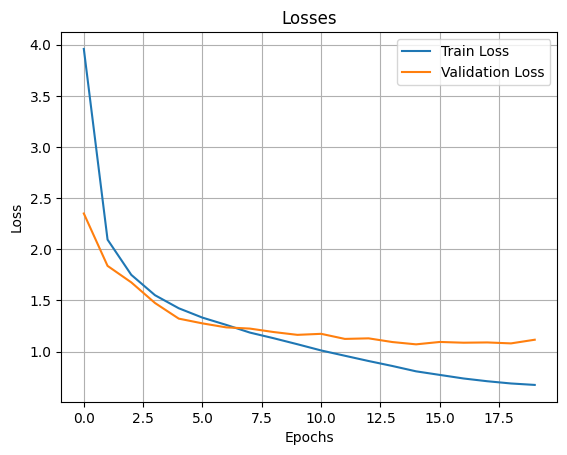

In [ ]:
# plot
plot_losses(tr_loss, vl_loss)

In [ ]:
cvt_acc= evaluate_model(cvt_model, test_loader, device, verbose=True)

Accuracy: 76.57%


In [ ]:
# --- CvT-21 ---
in_channels= 3
num_classes= 10
pool_type= 'cls'
dropout= 0.1
drop_path= 0.1

cvt_model= CvT(model_hparameters['cvt_21'], in_channels, num_classes, pool_type, dropout, drop_path).to(device)
count_parameters(cvt_model)

# train_loader has size 352, so 20 epochs have 7,040 steps
epochs= 20
steps= len(train_loader) * epochs
learning_rate= 3e-4

max_lr= learning_rate
min_lr= 3e-5
warmup_steps= 704  # 2 epochs of warmup
max_steps= steps

optimizer= torch.optim.AdamW(
    cvt_model.parameters(), lr=learning_rate, betas=(0.9, 0.999), weight_decay=0.1,
    fused=use_fused
)
print(f"Using fused AdamW: {use_fused}")
criterion= nn.CrossEntropyLoss(label_smoothing=0.1)
# for decreasing learning rate -- the CosineLRDecay is designed to be used per step
scheduler= CosineLRDecay(optimizer, min_lr, max_lr, warmup_steps, max_steps)

Number of parameters: 31219978
Using fused AdamW: True


In [ ]:
tr_loss, vl_loss= trainer(cvt_model, train_loader, val_loader, optimizer, criterion, scheduler,
                          epochs, device, eval_interval=1, verbose=True)

Epoch: 0 | Train Loss: 5.4964 | Val Loss: 2.6226 | dt/epoch: 122065.77ms
Epoch: 1 | Train Loss: 2.2765 | Val Loss: 1.9156 | dt/epoch: 123032.57ms
Epoch: 2 | Train Loss: 1.8105 | Val Loss: 1.5872 | dt/epoch: 122821.38ms
Epoch: 3 | Train Loss: 1.5611 | Val Loss: 1.5621 | dt/epoch: 122248.64ms
Epoch: 4 | Train Loss: 1.4313 | Val Loss: 1.4051 | dt/epoch: 121896.80ms
Epoch: 5 | Train Loss: 1.3276 | Val Loss: 1.2943 | dt/epoch: 122248.92ms
Epoch: 6 | Train Loss: 1.2437 | Val Loss: 1.2441 | dt/epoch: 122196.14ms
Epoch: 7 | Train Loss: 1.1764 | Val Loss: 1.1829 | dt/epoch: 121944.71ms
Epoch: 8 | Train Loss: 1.1061 | Val Loss: 1.1789 | dt/epoch: 122379.42ms
Epoch: 9 | Train Loss: 1.0433 | Val Loss: 1.2087 | dt/epoch: 121975.30ms
Epoch: 10 | Train Loss: 0.9934 | Val Loss: 1.1503 | dt/epoch: 121749.64ms
Epoch: 11 | Train Loss: 0.9313 | Val Loss: 1.1093 | dt/epoch: 121779.68ms
Epoch: 12 | Train Loss: 0.8778 | Val Loss: 1.0888 | dt/epoch: 122375.35ms
Epoch: 13 | Train Loss: 0.8268 | Val Loss: 1.085

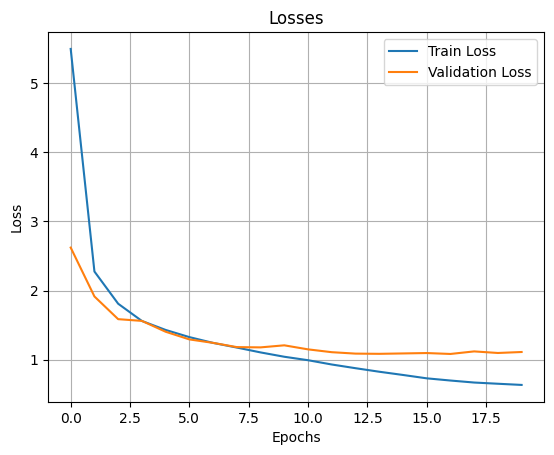

In [ ]:
# plot
plot_losses(tr_loss, vl_loss)

In [ ]:
cvt_acc= evaluate_model(cvt_model, test_loader, device, verbose=True)

Accuracy: 76.88%


Convolutional Vision Transformers fuse the strengths of CNNs and ViTs, offering efficiency, flexibility, and performance for modern vision tasks.

CvT vs. ViT vs. CNNs:

- Vs. ViT: CvT is more data-efficient and resolution-flexible due to convolutional embeddings.

- Vs. CNNs: CvT captures global context, unlike CNNs' local focus.

In [ ]:
# https://medium.com/@ovularslan/cvt-the-best-of-cnns-and-transformers-for-visual-recognition-pytorch-implementation-1f4add8f4787
# https://ai.plainenglish.io/convolutional-vision-transformers-blending-cnns-and-transformers-for-vision-48c1519fbe22